In [1]:
import numpy as np
import torch
import scipy
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

from place_cells import PlaceCells1D
from trajectory_generator import TrajectoryGenerator1D

from model import *
from get_data import *
from trainer import PCTrainer
from visualize import *

## Explorations

In [63]:
# generate a batch for visualization
class Options():
    Np = 20
    track_length = 1
    place_cell_rf = None
    plce_cell_seed = 0
    device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
    periodic = False
    batch_size = 5
    seq_len = 20
    dt = 0.1 # larger dt results in discontinuous place cell activations, which isn't bad
options = Options()

place_cell = PlaceCells1D(options)
generator = TrajectoryGenerator1D(options, place_cell)

input, activation, pos = generator.get_test_batch()
velocity, init_activation = input
print(velocity.shape, init_activation.shape, activation.shape, pos.shape)


torch.Size([5, 20, 1]) torch.Size([5, 20]) torch.Size([5, 20, 20]) torch.Size([5, 20, 1])


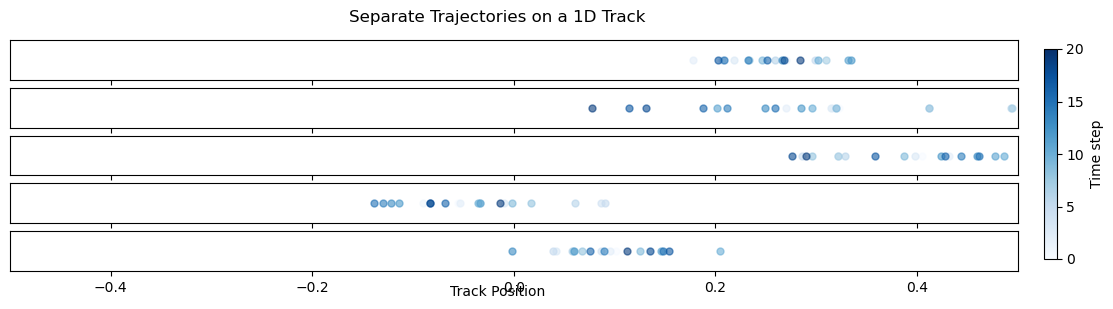

In [64]:
trajectories = pos[:5].cpu().numpy()
l = options.track_length / 2
fig, axes = plt.subplots(5, 1, figsize=(13, 3), sharex=True)

# Colormap for the time points in each trajectory
time_cmap = plt.cm.Blues

# Normalize the time points for the colormap
norm = plt.Normalize(0, trajectories.shape[1])

# Plot each trajectory in its own subplot
for i, (ax, traj) in enumerate(zip(axes, trajectories)):
    for j, point in enumerate(traj):
        ax.plot(point, 0, 'o', color=time_cmap(norm(j)), markersize=5, alpha=0.6)
    
    ax.set_xlim(-l, l)
    ax.set_ylim(-0.1, 0.1)
    ax.get_yaxis().set_visible(False)  # Hide the y-axis
    # ax.get_xaxis().set_visible(False)  # Hide the x-axis

fig.text(0.5, 0.04, 'Track Position', ha='center', va='center')
fig.suptitle('Separate Trajectories on a 1D Track')

# add a colorbar for the time points
cbar_ax = fig.add_axes([0.92, 0.15, 0.01, 0.7])
sm = plt.cm.ScalarMappable(cmap=time_cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, label='Time step')

plt.show()

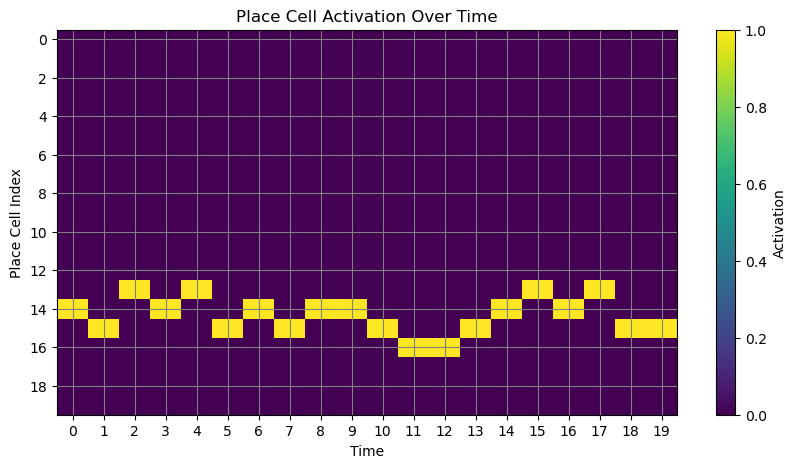

In [65]:
# visualize the place cell activations, sorted by the center of the place cell
sort_idx = np.argsort(place_cell.centers.cpu().numpy())
sample_activation = activation[0].cpu().numpy()
sample_activation = sample_activation[:, sort_idx]
plt.figure(figsize=(10, 5))
plt.imshow(sample_activation.T, aspect='auto', cmap='viridis')
plt.yticks(np.arange(0, options.Np, options.Np/10))
plt.xticks(np.arange(0, options.seq_len, 1))
plt.colorbar(label='Activation')
plt.xlabel('Time')
plt.ylabel('Place Cell Index') 
plt.title('Place Cell Activation Over Time')
ax = plt.gca()
ax.grid(color='gray')
plt.show()

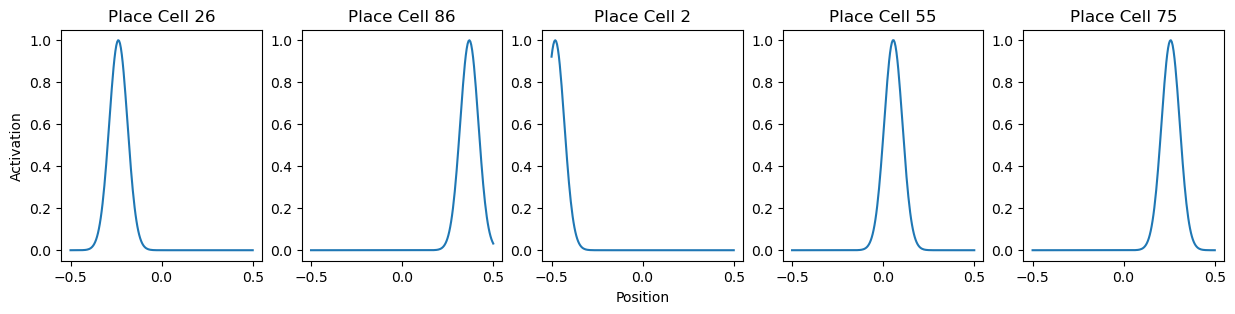

In [53]:
# visualize the place fields by plotting them on a grid
# uniformly sample the position
res = 200
pos = np.linspace(-options.track_length/2, options.track_length/2, res)
pos = torch.tensor(pos).unsqueeze(0).unsqueeze(-1).to(options.device)
activation = place_cell.get_activation(pos).cpu().numpy()
activation = activation.squeeze(0)

# visualize a few place fields
n = 5
fig, axes = plt.subplots(1, n, figsize=(15, 3))
rdn_idx = np.random.choice(options.Np, n, replace=False)
for i, idx in enumerate(rdn_idx):
    axes[i].plot(np.linspace(-options.track_length/2, options.track_length/2, res), activation[:, idx])
    axes[i].set_title(f'Place Cell {idx}')
    # set overall x and y labels
    if i == 0:
        axes[i].set_ylabel('Activation')
    if i == n // 2:
        axes[i].set_xlabel('Position')
plt.show()

When Np is small, because of the randomness and sparsity of place cell centers, many positions will excite one single place cell.

## Training tPC

In [6]:
class Options():
    device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
    oned = True
    Np = 100
    Ng = 20
    Nv = 1
    track_length = 1.0
    place_cell_rf = 0.05 # None for one-hot encoding of place cells
    plce_cell_seed = 0
    periodic = False
    seq_len = 20
    dt = 0.01
    batch_size = 500
    n_epochs = 20
    n_steps = 10
    learning_rate = 2e-3
    weight_decay = 1e-3
    decay_step_size = 10
    decay_rate = 0.9 
    lambda_z = 0. # sparse penalty for the temporal model
    lambda_z_init = 0. # sparse penalty for the initial static model
    inf_iters = 20 
    test_inf_iters = 300 # inference iterations during testing, for the initial static model
    inf_lr = 1e-2
    out_activation = utils.Softmax()
    rec_activation = utils.Tanh()
options = Options()
options.save_dir = './results/1d_tpc'
if not os.path.exists(options.save_dir):
    os.makedirs(options.save_dir)

place_cell = PlaceCells1D(options)
generator = TrajectoryGenerator1D(options, place_cell)

model = TemporalPCN(options).to(options.device)
init_model = HierarchicalPCN(options).to(options.device)
trainer = PCTrainer(options, model, init_model, generator, place_cell, restore=False)


In [3]:
trainer.train(save=True, preloaded_data=True)

Loading pre-generated data at data/trajectory1d\5000_20_100_001.npz...


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1/20. Loss: 37.5114. PC Energy: 37.7037. Err: 34.41 cm.: 100%|██████████| 10/10 [00:05<00:00,  1.79it/s]
Epoch: 2/20. Loss: 36.9481. PC Energy: 37.1108. Err: 25.82 cm.: 100%|██████████| 10/10 [00:05<00:00,  1.87it/s]
Epoch: 3/20. Loss: 36.812. PC Energy: 36.957. Err: 14.27 cm.: 100%|██████████| 10/10 [00:05<00:00,  1.85it/s] 
Epoch: 4/20. Loss: 36.7214. PC Energy: 36.8629. Err: 11.73 cm.:  10%|█         | 1/10 [00:00<00:05,  1.71it/s]


KeyboardInterrupt: 

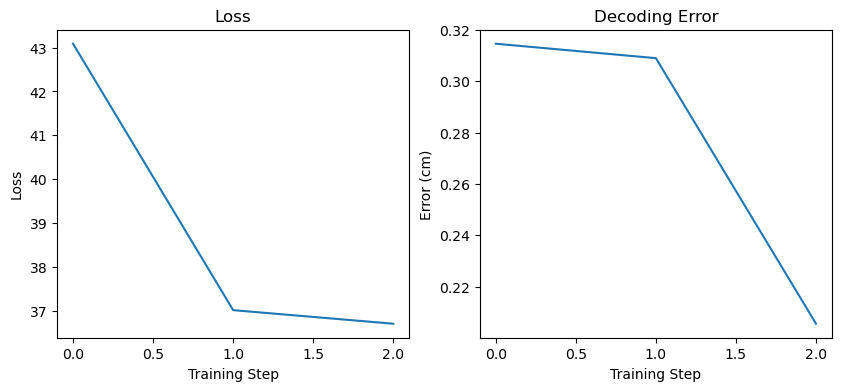

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(trainer.loss)
axes[0].set_title('Loss')
axes[0].set_xlabel('Training Step')
axes[0].set_ylabel('Loss')
axes[1].plot(trainer.err)
axes[1].set_title('Decoding Error')
axes[1].set_xlabel('Training Step')
axes[1].set_ylabel('Error (cm)')
plt.show()

tensor(0.2993, dtype=torch.float64)
torch.Size([5, 20, 1])


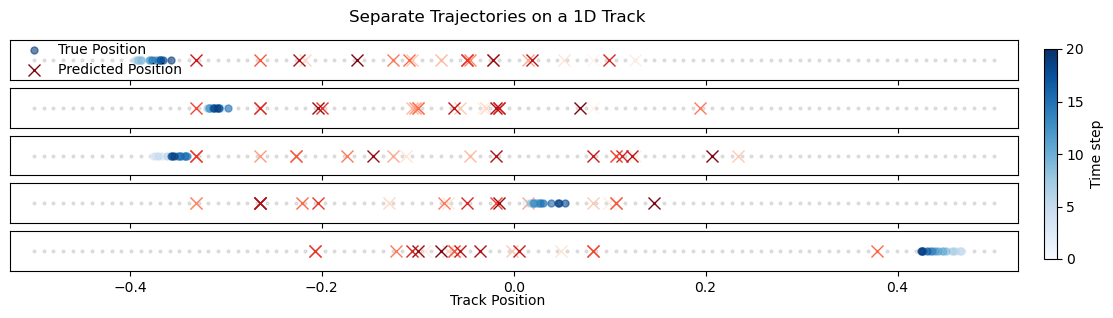

In [7]:
plot_1d_performance(place_cell, generator, options, trainer)

In [8]:
rate_map = compute_1d_ratemaps(model, trainer, generator, options, n_avg=200, res=200, Ng=options.Ng)


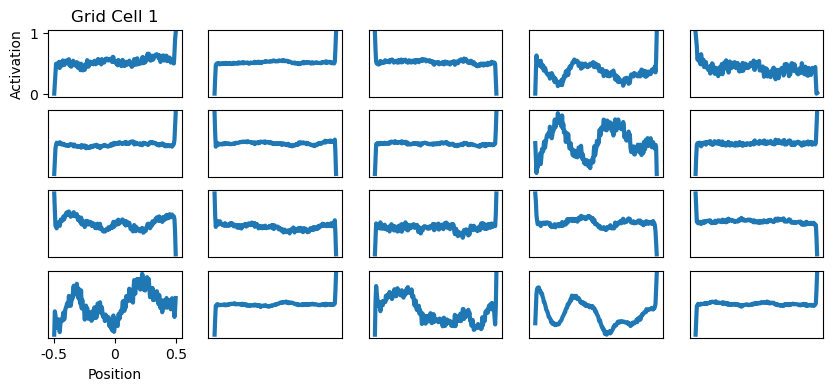

In [9]:
# visualize the rate maps
plot_1d_ratemaps(rate_map, options)